# SMC Pretuning

In [1]:
import jax
from jax import numpy as jnp
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import functools
from datetime import date

rng_key = jax.random.key(int(date.today().strftime("%Y%m%d")))

## Define density and initial particles

In [2]:
n_particles = 5000

In [3]:
from jax.scipy.stats import multivariate_normal


def V(x):
    return 5 * jnp.sum(jnp.square(x**2 - 1))


def prior_log_prob(x):
    d = x.shape[0]
    return multivariate_normal.logpdf(x, jnp.zeros((d,)), jnp.eye(d))


loglikelihood = lambda x: -V(x)


def density():
    linspace = jnp.linspace(-2, 2, 5000).reshape(-1, 1)
    lambdas = jnp.linspace(0.0, 1.0, 5)
    prior_logvals = jnp.vectorize(prior_log_prob, signature="(d)->()")(linspace)
    potential_vals = jnp.vectorize(V, signature="(d)->()")(linspace)
    log_res = prior_logvals.reshape(1, -1) - jnp.expand_dims(
        lambdas, 1
    ) * potential_vals.reshape(1, -1)

    density = jnp.exp(log_res)
    normalizing_factor = jnp.sum(density, axis=1, keepdims=True) * (
        linspace[1] - linspace[0]
    )
    density /= normalizing_factor
    return density

In [4]:
def initial_particles_multivariate_normal(dimensions, key, n_samples):
    return jax.random.multivariate_normal(
        key, jnp.zeros(dimensions), jnp.eye(dimensions) * 2, (n_samples,)
    )

# IRMH Kernel without pretunning, but with covariance matrix tuning (single parameter for all chains)

In [5]:
from blackjax import adaptive_tempered_smc
from blackjax.smc import resampling as resampling, solver, extend_params
from blackjax import irmh
from blackjax import inner_kernel_tuning
from blackjax.smc.tuning.from_particles import (
    particles_covariance_matrix,
    particles_stds,
    particles_means,
)


def tuned_irmh_loop(kernel, rng_key, initial_state):
    def cond(carry):
        _, state, *_ = carry
        return state.sampler_state.lmbda < 1

    def body(carry):
        i, state, op_key = carry
        op_key, subkey = jax.random.split(op_key, 2)
        state, info = kernel(subkey, state)
        return i + 1, state, op_key

    def f(initial_state, key):
        total_iter, final_state, _ = jax.lax.while_loop(
            cond, body, (0, initial_state, key)
        )
        return total_iter, final_state

    total_iter, final_state = f(initial_state, rng_key)
    return total_iter, final_state.sampler_state.particles
    
def irmh_full_cov_experiment(dimensions, target_ess, num_mcmc_steps):
    kernel = irmh.build_kernel()
    def step(key, state, logdensity, means, cov):
        "We need step to be vmappable over the parameter space, so we wrap it to make all parameter Jax Arrays or JaxTrees"
        proposal_distribution = lambda key: jax.random.multivariate_normal(
            key, means, cov
        )

        def proposal_logdensity_fn(proposal, state):
            return jnp.log(
                jax.scipy.stats.multivariate_normal.pdf(
                    state.position, mean=means, cov=cov
                )
            )

        return kernel(key, state, logdensity, proposal_distribution, proposal_logdensity_fn)
            

    def mcmc_parameter_update_fn(key, state, info):
        covariance = jnp.atleast_2d(particles_covariance_matrix(state.particles))
        return extend_params({"means":particles_means(state.particles), "cov":covariance})

    kernel_tuned_proposal = inner_kernel_tuning(
        logprior_fn=prior_log_prob,
        loglikelihood_fn=loglikelihood,
        mcmc_step_fn=step,
        mcmc_init_fn=irmh.init,
        resampling_fn=resampling.systematic,
        smc_algorithm=adaptive_tempered_smc,
        mcmc_parameter_update_fn=mcmc_parameter_update_fn,
        initial_parameter_value=extend_params({"means":jnp.zeros(dimensions), "cov":jnp.eye(dimensions) * 2}),
        target_ess=target_ess,
        num_mcmc_steps=num_mcmc_steps,
    )

    return kernel_tuned_proposal, tuned_irmh_loop

In [6]:
def smc_run_experiment(runnable, target_ess, num_mcmc_steps, dimen, key=rng_key):
    key, initial_particles_key, iterations_key = jax.random.split(key, 3)
    initial_particles = initial_particles_multivariate_normal(
        dimen, initial_particles_key, n_particles
    )
    kernel, inference_loop = runnable(dimen, target_ess, num_mcmc_steps)
    _, particles = inference_loop(
        kernel.step, iterations_key, kernel.init(initial_particles)
    )
    return particles

In [7]:
dimensions_to_try = [10, 20, 30]

In [8]:
experiments = []
dimensions = []
particles = []
for dims in dimensions_to_try:
    for exp_id, experiment in (
        ("tune_full_cov", irmh_full_cov_experiment),
    ):
        experiment_particles = smc_run_experiment(experiment, 0.5, 20, dims)
        experiments.append(exp_id)
        dimensions.append(dims)
        particles.append(experiment_particles)

In [9]:
results = pd.DataFrame(
    {"experiment": experiments, "dimensions": dimensions, "particles": particles}
)

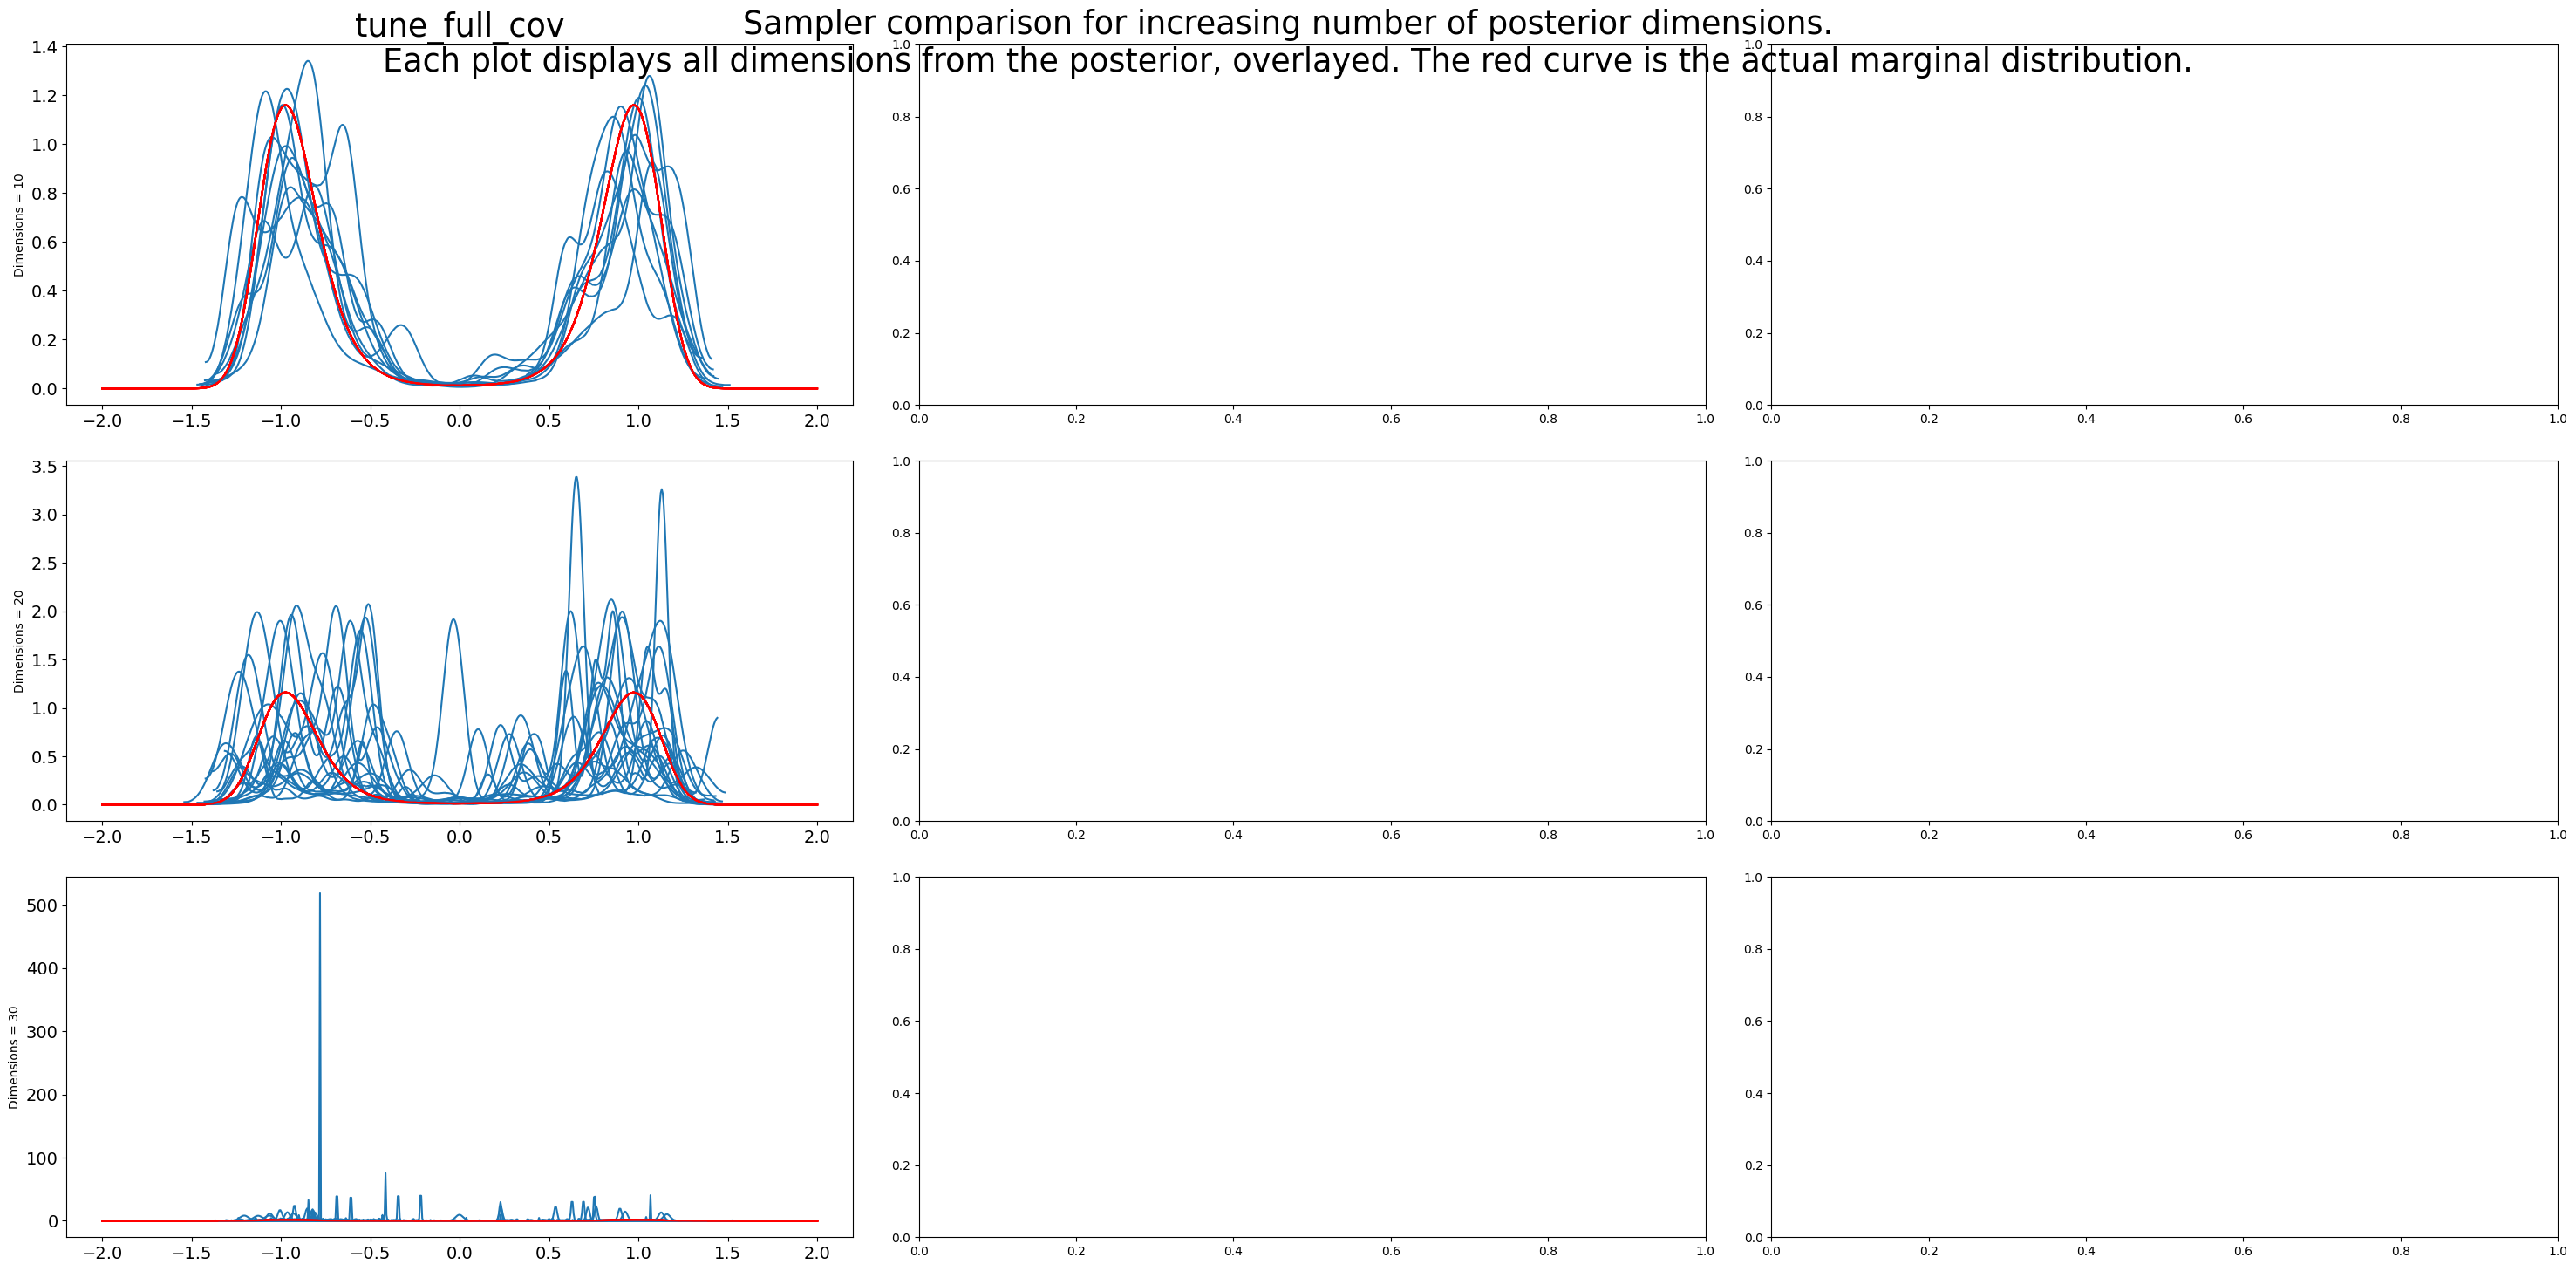

In [10]:
linspace = jnp.linspace(-2, 2, 5000).reshape(-1, 1).squeeze()


def plot(post, sampler, dimensions, ax):
    post = np.asarray(post)
    dimensions = post.shape[1]
    for dim in range(dimensions):
        az.plot_kde(post[:, dim], ax=ax)
        _ = ax.plot(linspace, density()[-1], c="red")
rows = len(dimensions_to_try)
cols = 3
samplers = ["tune_full_cov",]
fig, axs = plt.subplots(rows, cols, figsize=(cols * 10, rows * 5))

plt.rcParams.update({"font.size": 22})

for ax, lab in zip(axs[:, 0], dimensions_to_try):
    ax.set(ylabel=f"Dimensions = {lab}")

for ax, lab in zip(axs[0, :], samplers):
    ax.set(title=lab)

for col, experiment in enumerate(samplers):
    for row, dimension in enumerate(dimensions_to_try):
        particles = (
            results[
                (results.experiment == experiment) & (results.dimensions == dimension)
            ]
            .iloc[0]
            .particles
        )
        plot(particles, experiment, dimension, axs[row, col])

fig.tight_layout()
fig.suptitle(
    """Sampler comparison for increasing number of posterior dimensions.
Each plot displays all dimensions from the posterior, overlayed. The red curve is the actual marginal distribution."""
)
plt.show()

# Pretuning

In [11]:
import unittest

import chex
import jax
import jax.numpy as jnp
import numpy as np
from absl.testing import absltest

import blackjax
from blackjax.smc import extend_params, resampling
from blackjax.smc.pretuning import build_pretune, esjd, update_parameter_distribution

def pretuning_experiment(dimensions, target_ess, num_mcmc_steps):
    key = jax.random.PRNGKey(50)
    dimen=dimensions
    key, initial_particles_key, iterations_key = jax.random.split(key, 3)
    initial_particles = initial_particles_multivariate_normal(
            dimen, initial_particles_key, n_particles
    )
    sampling_key, step_size_key, integration_steps_key = jax.random.split(
        key, 3
    )

    # Set initial samples for integration steps and step sizes.
    integration_steps_distribution = jnp.round(
        jax.random.uniform(
            integration_steps_key, (n_particles,), minval=1, maxval=100
        )
    ).astype(int)
    
    step_sizes_distribution = jax.random.uniform(
        step_size_key, (n_particles,), minval=1e-2, maxval=1e-1
    )
    
    # Fixes inverse_mass_matrix and distribution for the other two parameters.
    initial_parameters = dict(
        inverse_mass_matrix=extend_params(jnp.eye(dimen)),
        step_size=step_sizes_distribution,
        num_integration_steps=integration_steps_distribution,
    )
    
    # As many parameters samples as particles
    assert initial_parameters["step_size"].shape == (n_particles,)
    assert initial_parameters["num_integration_steps"].shape == (n_particles,)

    # Pretuning step.
    pretune = build_pretune(
        blackjax.hmc.init,
        blackjax.hmc.build_kernel(),
        alpha=5,
        n_particles=n_particles,
        sigma_parameters={"step_size": 0.1, "num_integration_steps": 2},
        parameters_to_pretune=["step_size", "num_integration_steps"],
        round_to_integer=["num_integration_steps"],
    )

    # SMC definition
    init2, smc_kernel = blackjax.smc.pretuning.build_kernel(blackjax.tempered_smc,
        prior_log_prob,
        loglikelihood,
        blackjax.hmc.build_kernel(),
        blackjax.hmc.init,
        resampling.systematic,
        num_mcmc_steps=num_mcmc_steps,
        pretune_fn=pretune)
    
    # Loop
    def body_fn(carry, lmbda):
        i, state = carry
        subkey = jax.random.fold_in(iterations_key, i)
        new_state, info = smc_kernel(subkey, state, lmbda=lmbda)
        return (i + 1, new_state), (new_state, info)
    
    a = init2(blackjax.tempered_smc.init, initial_particles, initial_parameters)

    # Run sampling
    num_tempering_steps = 20
    lambda_schedule = np.logspace(-5, 0, num_tempering_steps)
    (_, result), _ = jax.lax.scan(body_fn, (0, a), lambda_schedule)
    
    return result.sampler_state.particles, result   
    


# Plotting code

In [12]:
linspace = jnp.linspace(-2, 2, 5000).reshape(-1, 1).squeeze()
cols=3
rows=3
def plot(post, sampler, dimensions, ax):
    post = np.asarray(post)
    dimensions = post.shape[1]
    for dim in range(dimensions):
        az.plot_kde(post[:, dim], ax=ax)
        _ = ax.plot(linspace, density()[-1], c="red")

In [13]:
result1, final_state_1 = pretuning_experiment(10, 0.5, 20)

In [14]:
result2, final_state_2 = pretuning_experiment(20, 0.5, 20)

In [15]:
result3, final_state_3 = pretuning_experiment(30, 0.5, 20)

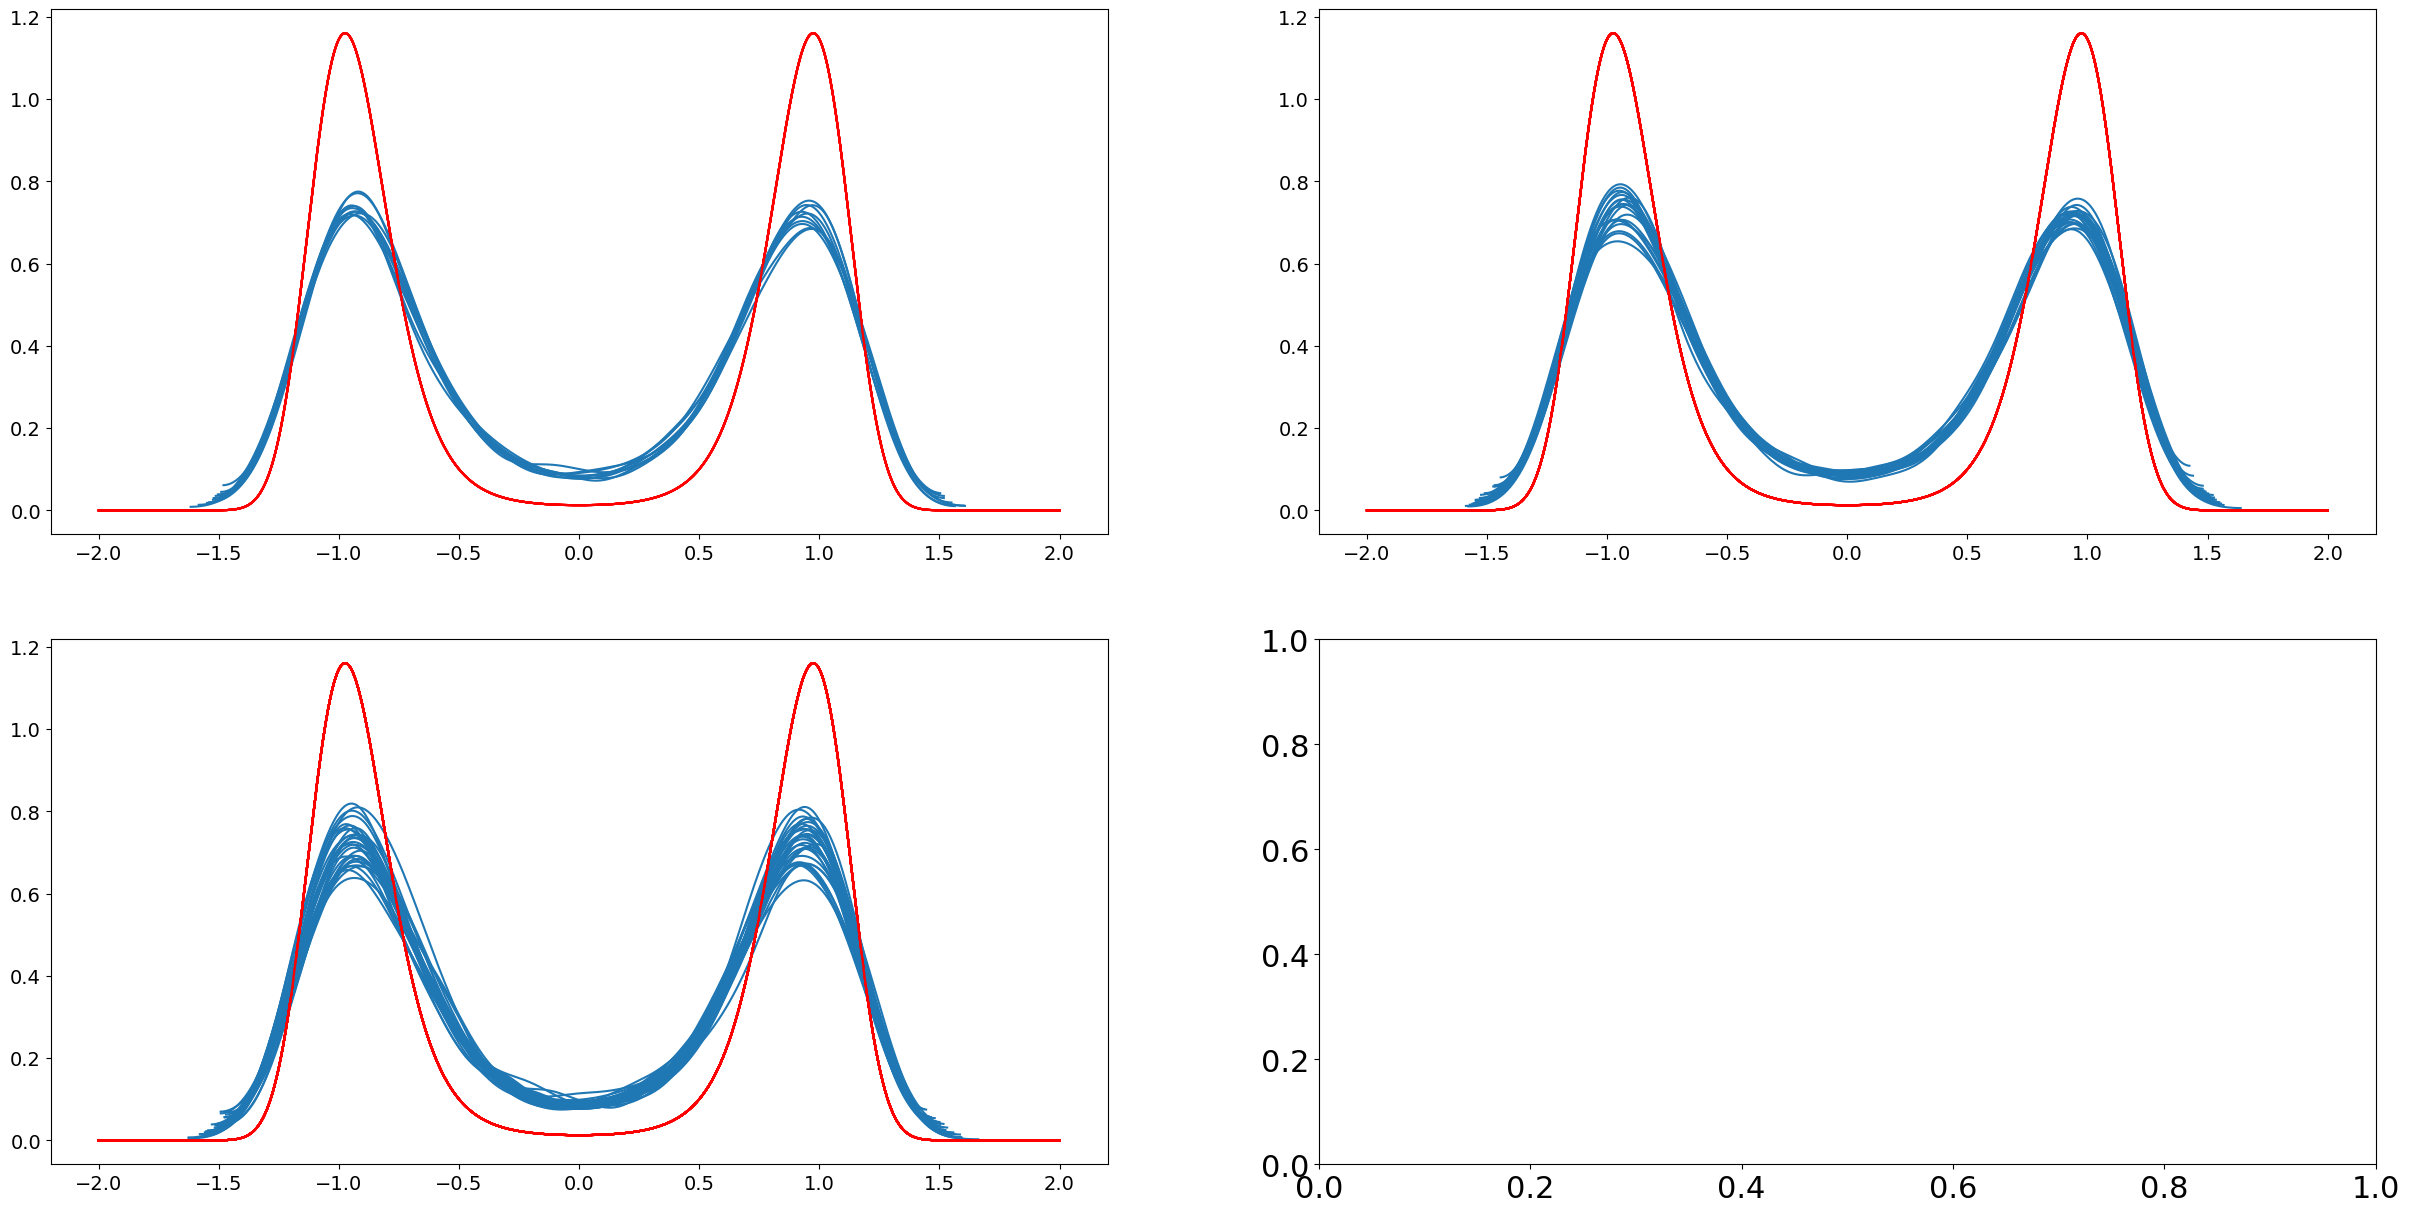

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(cols * 10, rows * 5))
plot(result1, "pretuning", 10, axs[0,0])
plot(result2, "pretuning", 10, axs[0,1])
plot(result3, "pretuning", 10, axs[1,0])

<Axes: >

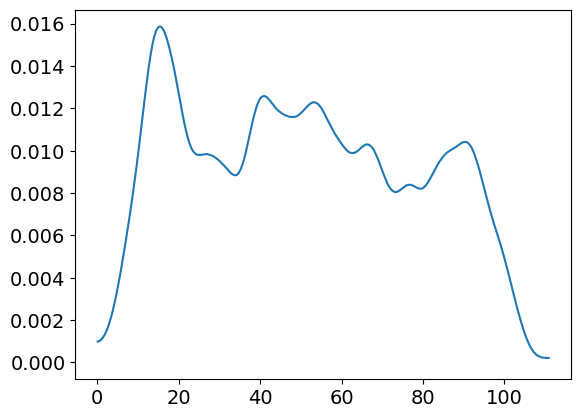

In [17]:
az.plot_kde(final_state_1.parameter_override["num_integration_steps"])

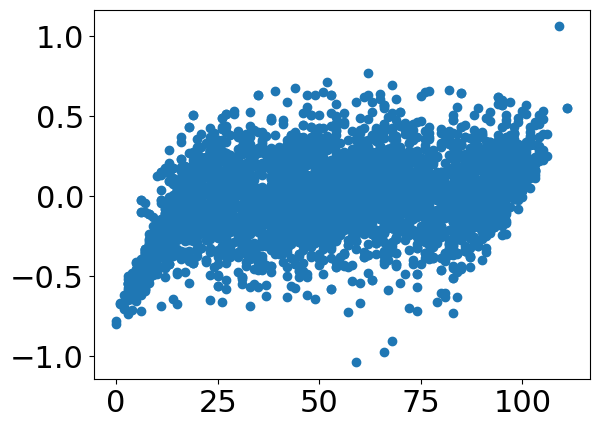

In [18]:
plt.scatter(final_state_1.parameter_override["num_integration_steps"], final_state_1.parameter_override["step_size"])

<Axes: >

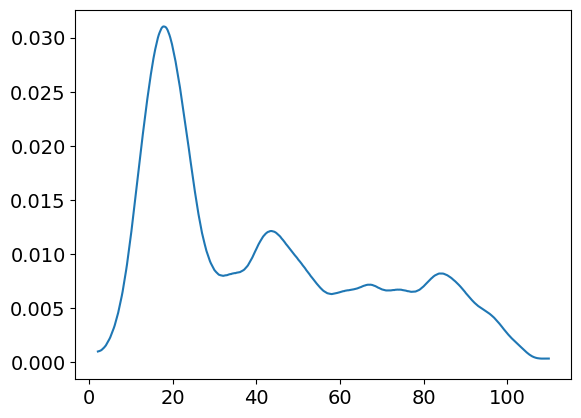

In [19]:
az.plot_kde(final_state_2.parameter_override["num_integration_steps"])

<Axes: >

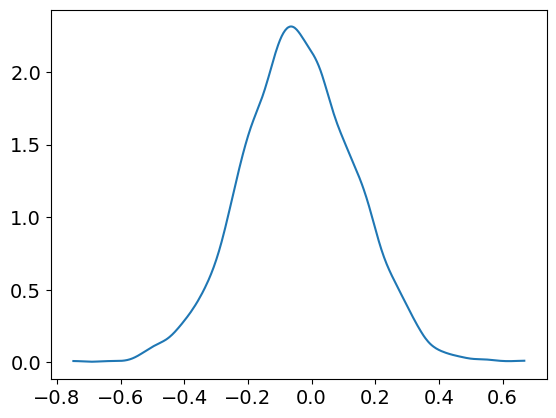

In [20]:
az.plot_kde(final_state_3.parameter_override["step_size"])

<Axes: >

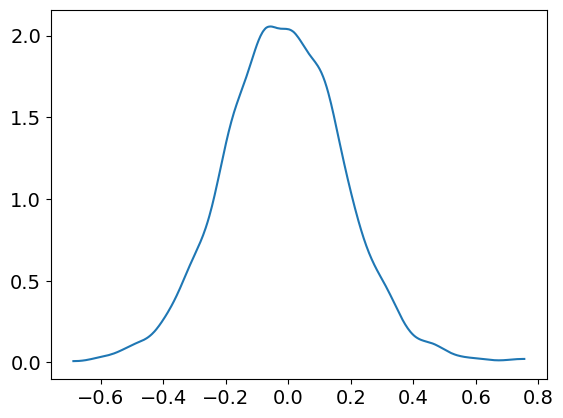

In [21]:
az.plot_kde(final_state_2.parameter_override["step_size"])

<Axes: >

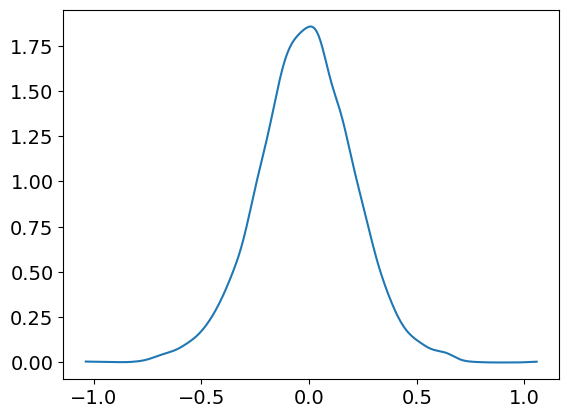

In [22]:
az.plot_kde(final_state_1.parameter_override["step_size"])

In [23]:
final_state_1.parameter_override["step_size"]

Array([ 0.30474865, -0.03949189, -0.03949189, ..., -0.02567597,
       -0.20529896, -0.20356935], dtype=float32)

# Adaptive tempered

In [24]:
def pretuning_experiment_adaptive(dimensions, target_ess, num_mcmc_steps):
    key = jax.random.PRNGKey(50)
    dimen=dimensions
    key, initial_particles_key, iterations_key = jax.random.split(key, 3)
    initial_particles = initial_particles_multivariate_normal(
            dimen, initial_particles_key, n_particles
    )
    sampling_key, step_size_key, integration_steps_key = jax.random.split(
        key, 3
    )

    # Set initial samples for integration steps and step sizes.
    integration_steps_distribution = jnp.round(
        jax.random.uniform(
            integration_steps_key, (n_particles,), minval=1, maxval=50
        )
    ).astype(int)
    
    step_sizes_distribution = jax.random.uniform(
        step_size_key, (n_particles,), minval=1e-2, maxval=1e-1
    )
    
    # Fixes inverse_mass_matrix and distribution for the other two parameters.
    initial_parameters = dict(
        inverse_mass_matrix=extend_params(jnp.eye(dimen)),
        step_size=step_sizes_distribution,
        num_integration_steps=integration_steps_distribution,
    )
    
    # As many parameters samples as particles
    assert initial_parameters["step_size"].shape == (n_particles,)
    assert initial_parameters["num_integration_steps"].shape == (n_particles,)

    # Pretuning step.
    pretune = build_pretune(
        blackjax.hmc.init,
        blackjax.hmc.build_kernel(),
        alpha=5,
        n_particles=n_particles,
        sigma_parameters={"step_size": 0.1, "num_integration_steps": 2},
        parameters_to_pretune=["step_size", "num_integration_steps"],
        round_to_integer=["num_integration_steps"],
    )

    # SMC definition
    init2, smc_kernel = blackjax.smc.pretuning.build_kernel(blackjax.adaptive_tempered_smc,
        prior_log_prob,
        loglikelihood,
        blackjax.hmc.build_kernel(),
        blackjax.hmc.init,
        resampling.systematic,
        num_mcmc_steps=num_mcmc_steps,
        pretune_fn=pretune,
        target_ess=target_ess)
    
    # Loop
    
    a = init2(blackjax.adaptive_tempered_smc.init, initial_particles, initial_parameters)

    # Run sampling
    key, initial_particles_key, iterations_key = jax.random.split(key, 3)
    initial_particles = initial_particles_multivariate_normal(
        dimen, initial_particles_key, n_particles
    )
    
    _, particles = tuned_irmh_loop(
        smc_kernel, iterations_key, a
    )

    
    return particles   
    


In [25]:
particles1 = pretuning_experiment_adaptive(10, 0.54, 10)
particles2 = pretuning_experiment_adaptive(20, 0.54, 10)
particles3 = pretuning_experiment_adaptive(30, 0.54, 10)


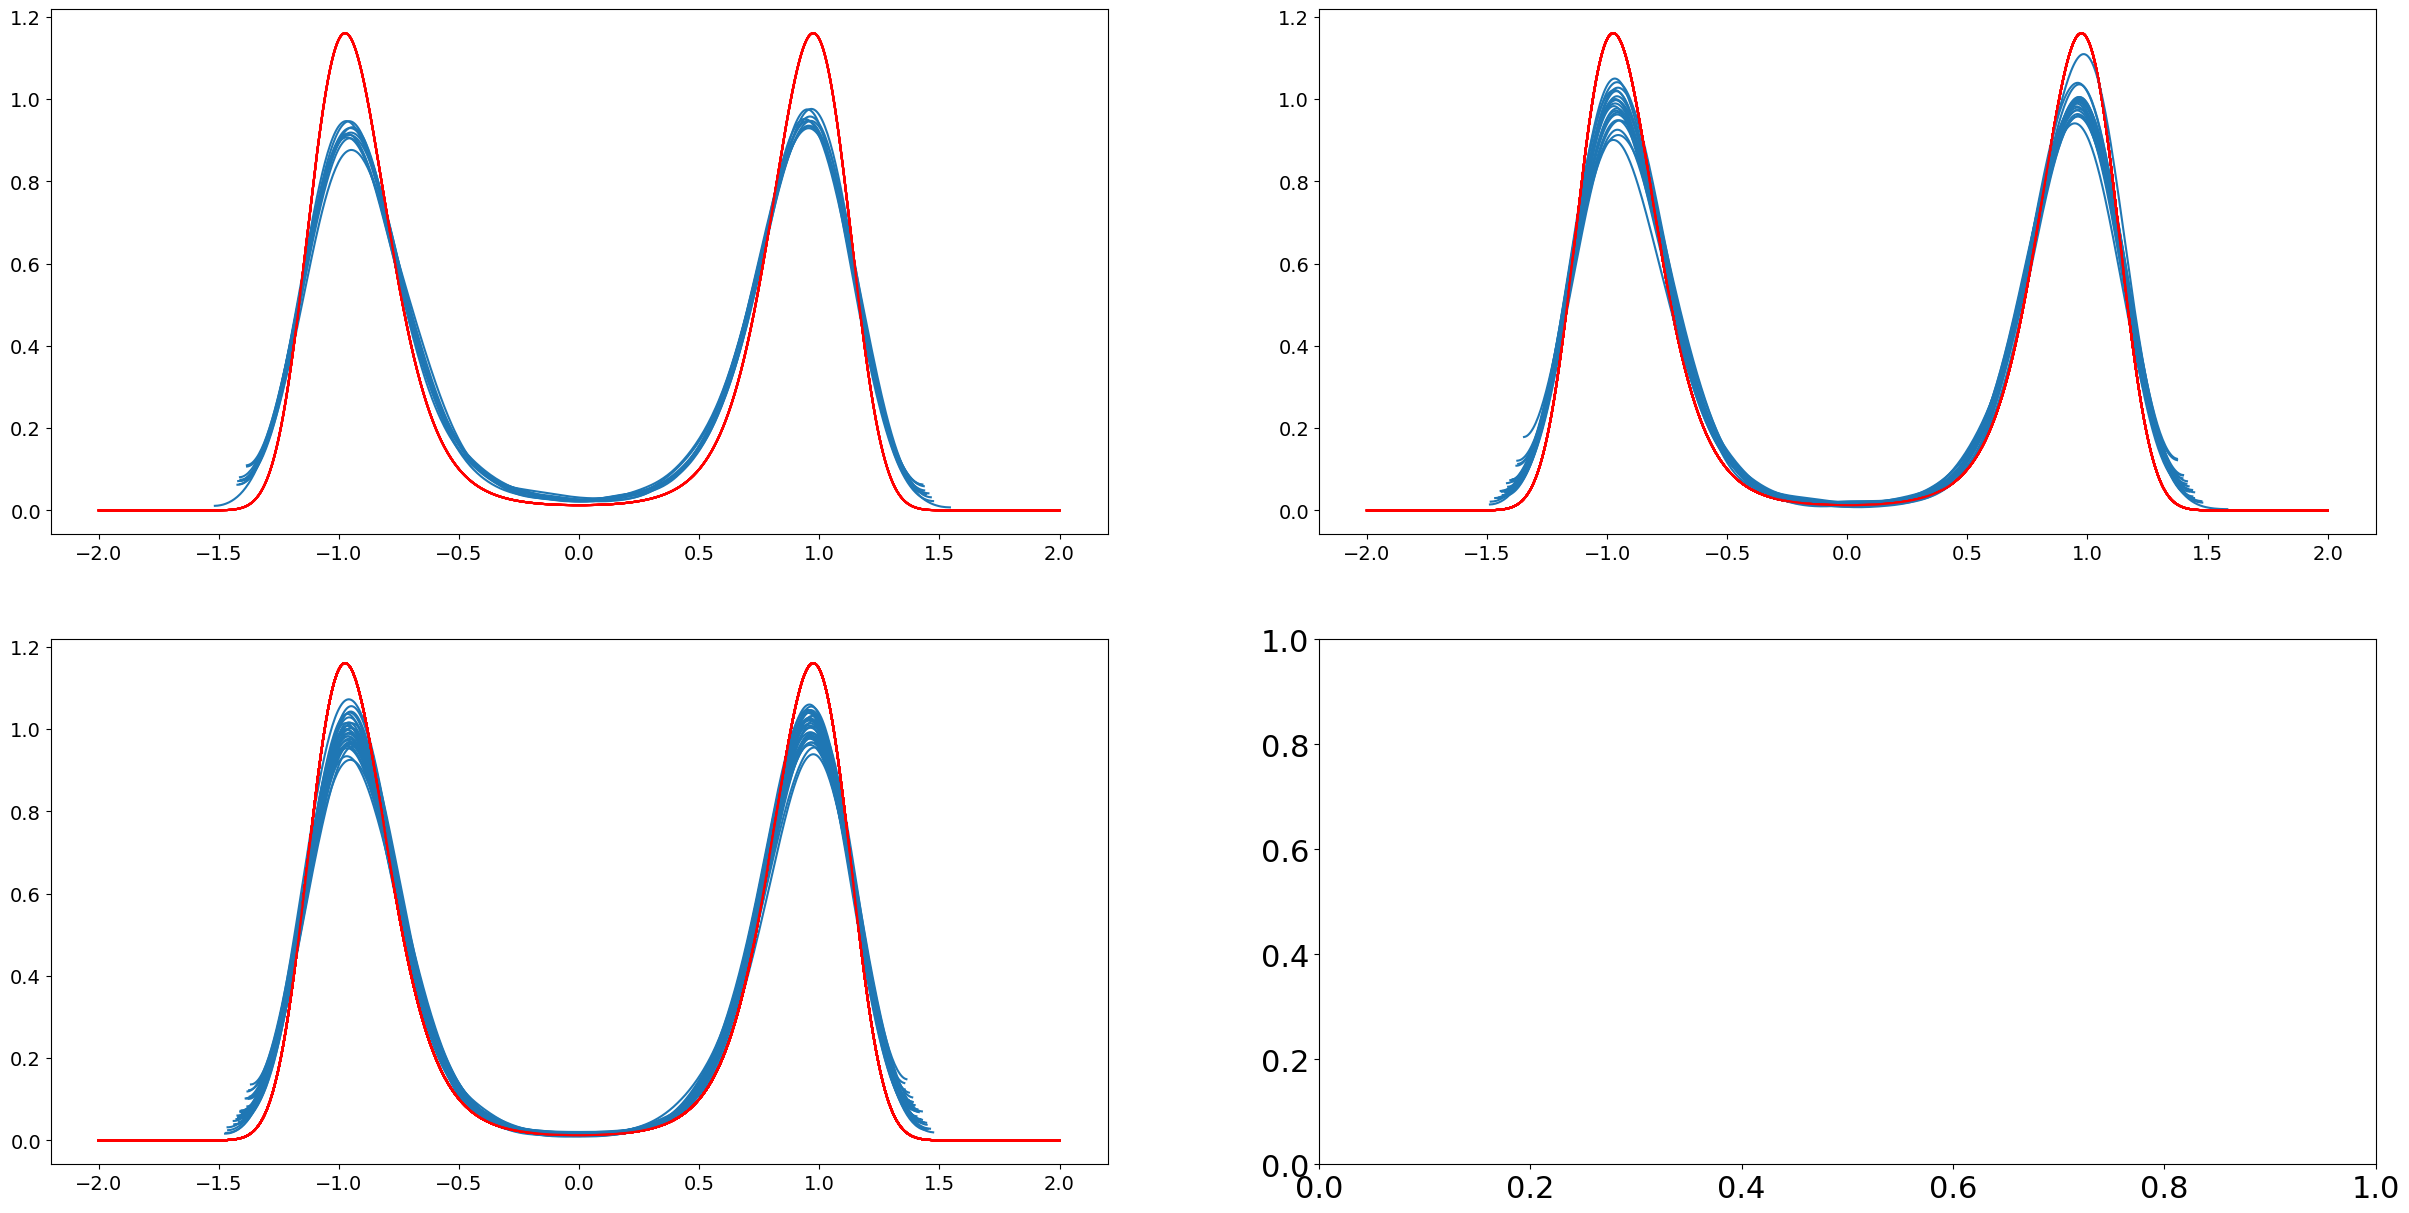

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(cols * 10, rows * 5))
plot(particles1, "pretuning_adaptive", 10, axs[0,0])
plot(particles2, "pretuning_adaptive", 20 , axs[0,1])
plot(particles3, "pretuning_adaptive", 30, axs[1,0])
